# Exploratory Data Analysis (EDA)

This is a crucial step in understanding the underlying patterns and characteristics of a dataset. In this notebook, we will perform EDA on our synthetic retail sales dataset to uncover insights and identify trends that can inform our forecasting models. We will explore various aspects of the data, including sales distribution, seasonality, and the impact of different features on demand. Let's dive in and analyze our dataset to gain a deeper understanding of the factors driving sales performance.


In [1]:
# 1. Sales Distribution Analysis
# Let's start by examining the distribution of sales across different stores and items. We will use visualizations such as histograms and box plots to understand the spread and central tendencies of sales data. This will help us identify any outliers or skewness in the sales distribution, which can impact our forecasting models.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load the clean data
df = pd.read_csv('../data/processed/cleaned_retail_sales.csv')
df['date'] = pd.to_datetime(df['date'])  # Ensure dates are datetime objects again


In [3]:
# Basic Dataset Overview
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nSummary Statistics:")
print(df.describe())


Dataset Shape: (4565000, 13)

Data Types:
store_id                int64
item_id                   str
category                  str
subcategory               str
price                 float64
demand                  int64
country                   str
city_tier                 str
date           datetime64[us]
year                    int64
month                   int64
day_of_week             int64
is_weekend              int64
dtype: object

Missing Values:
store_id       0
item_id        0
category       0
subcategory    0
price          0
demand         0
country        0
city_tier      0
date           0
year           0
month          0
day_of_week    0
is_weekend     0
dtype: int64

Summary Statistics:
           store_id         price        demand                        date  \
count  4.565000e+06  4.565000e+06  4.565000e+06                     4565000   
mean   2.834000e+02  2.153167e+02  7.741246e+01  2021-07-01 11:59:59.999999   
min    1.500000e+01  1.365000e+01  0.000000e+

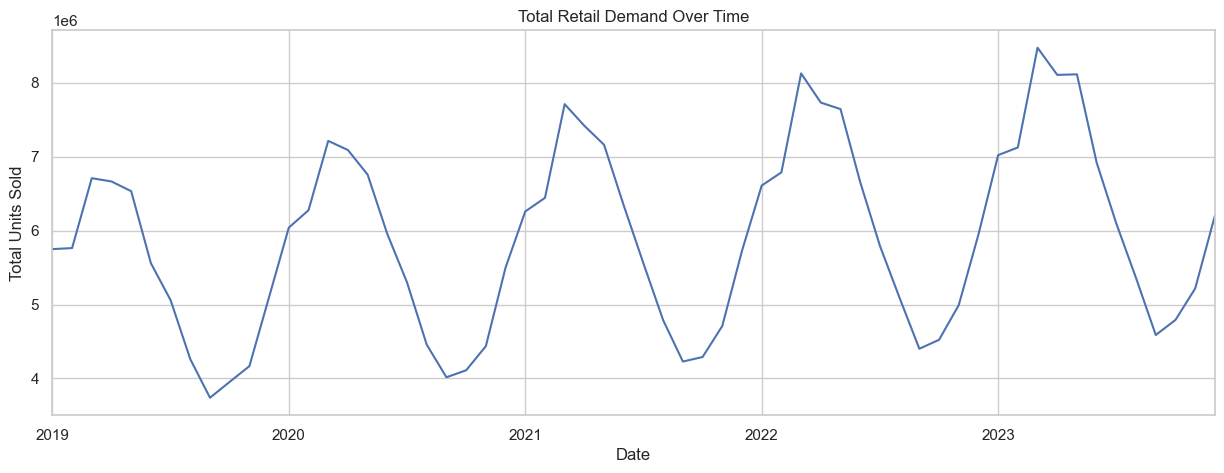

In [4]:
# 1. Total Demand over Time (The Big Picture)
plt.figure(figsize=(15, 5))
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['demand'].sum()
monthly_sales.plot()
plt.title('Total Retail Demand Over Time')
plt.ylabel('Total Units Sold')
plt.xlabel('Date')
plt.show()


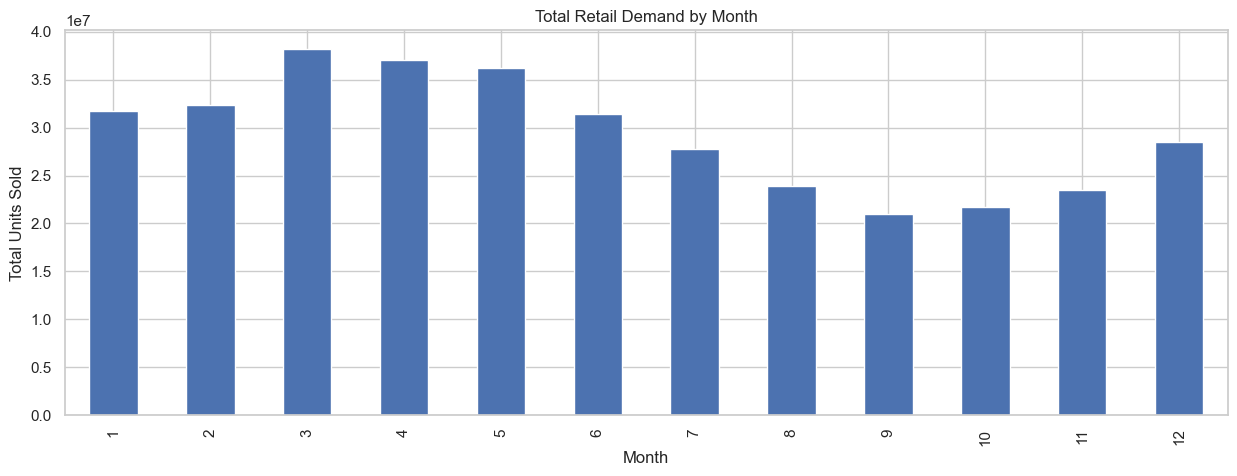

In [5]:
plt.figure(figsize=(15, 5))
new_monthly_sales = df.groupby('month')['demand'].sum()
new_monthly_sales.plot(kind='bar')
plt.title('Total Retail Demand by Month')
plt.ylabel('Total Units Sold')
plt.xlabel('Month')
plt.show()

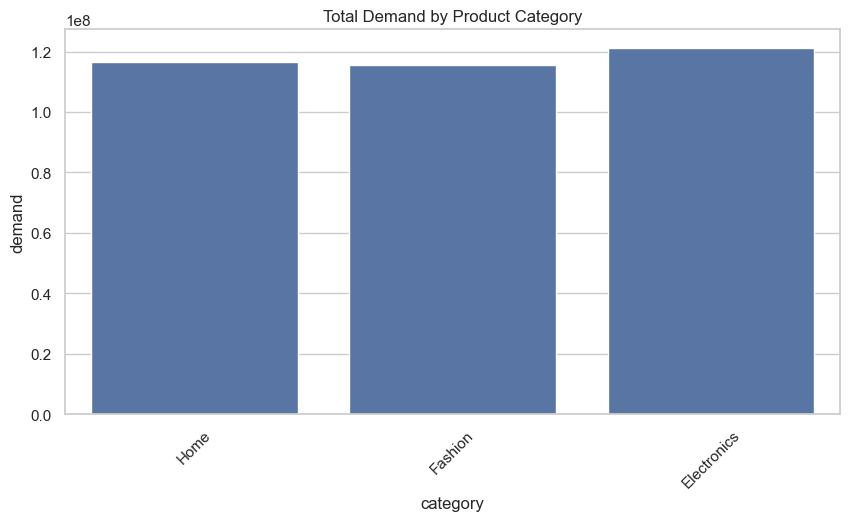

In [6]:
# 2. Demand by Category (What sells the most?)
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='category', y='demand', estimator=sum, errorbar=None)
plt.title('Total Demand by Product Category')
plt.xticks(rotation=45)
plt.show()


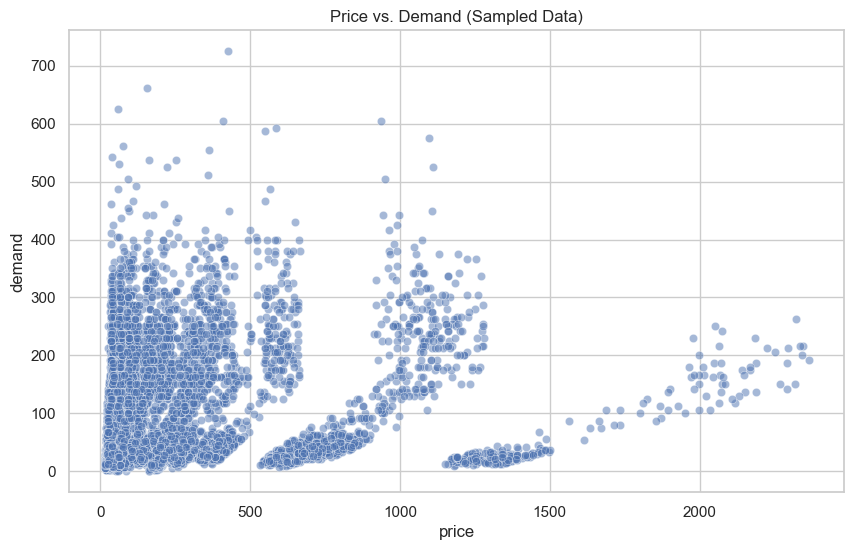

In [7]:
# 3. Price vs. Demand (The classic economic question)
# We sample the data to avoid plotting 4.5 million points!
sample_df = df.sample(10000, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x='price', y='demand', alpha=0.5)
plt.title('Price vs. Demand (Sampled Data)')
plt.show()


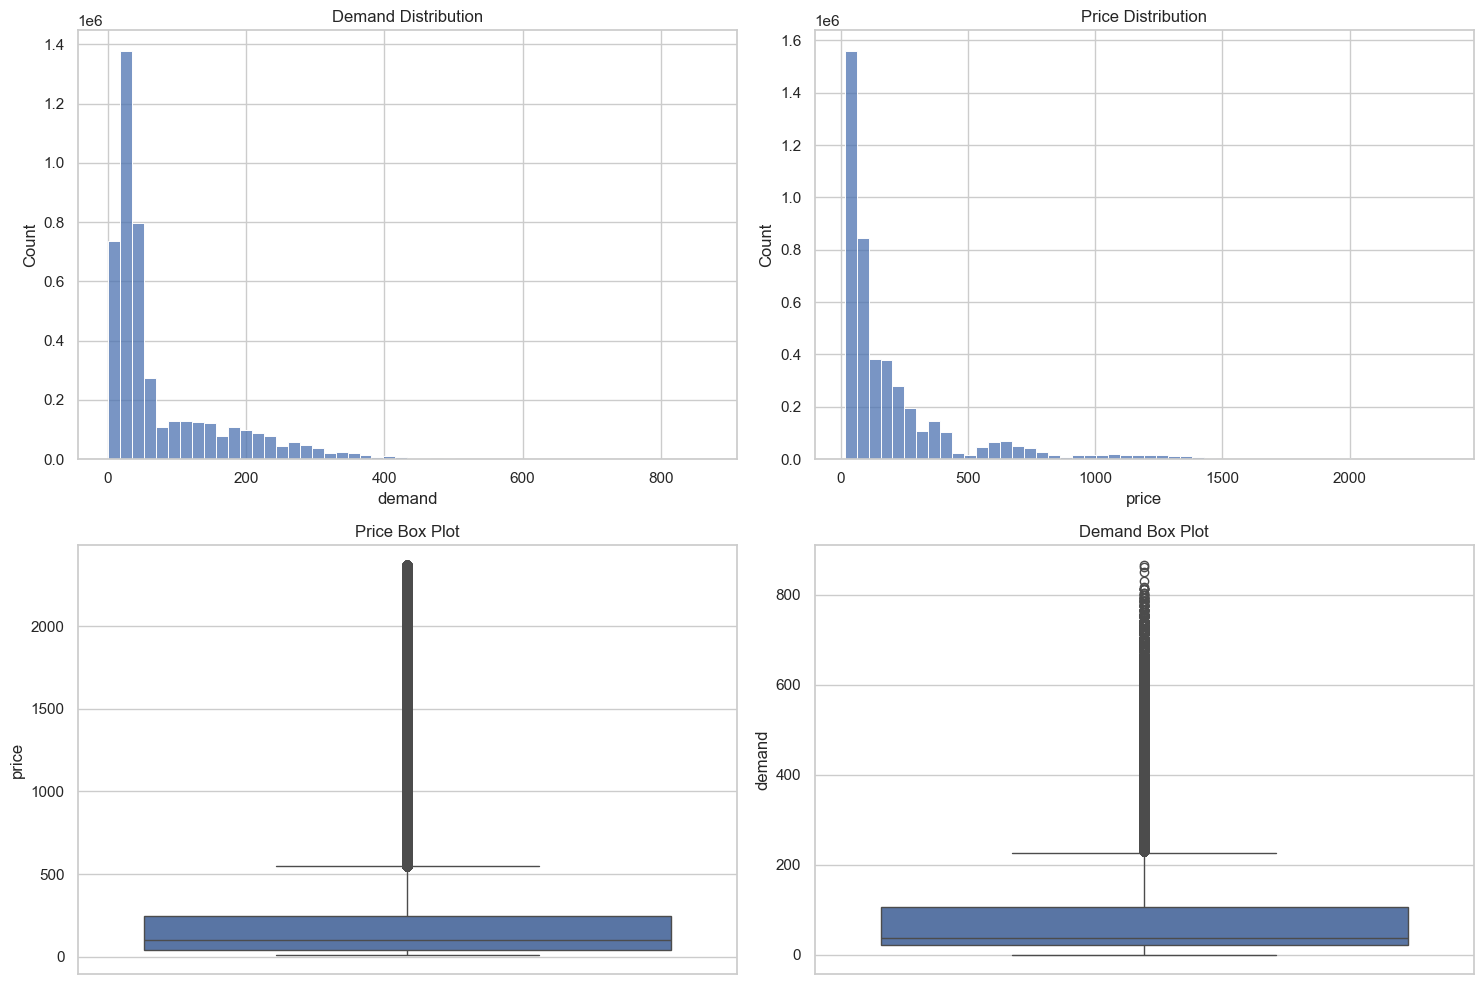

In [8]:
# 4. Distribution of Key Numerical Variables
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Demand distribution
sns.histplot(df['demand'], bins=50, ax=axes[0,0])
axes[0,0].set_title('Demand Distribution')

# Price distribution
sns.histplot(df['price'], bins=50, ax=axes[0,1])
axes[0,1].set_title('Price Distribution')

# Base price distribution (if it exists)
if 'base_price' in df.columns:
    sns.histplot(df['base_price'], bins=50, ax=axes[1,0])
    axes[1,0].set_title('Base Price Distribution')
else:
    sns.boxplot(y=df['price'], ax=axes[1,0])
    axes[1,0].set_title('Price Box Plot')

# Box plot for demand
sns.boxplot(y=df['demand'], ax=axes[1,1])
axes[1,1].set_title('Demand Box Plot')

plt.tight_layout()
plt.show()


### Explanation of the Code Above


The code above tells us about the distribution of demand and price in our dataset. The histograms show us how frequently different demand and price values occur, while the box plots help us identify any outliers in these variables. This information is crucial for understanding the overall sales patterns and for making informed decisions when building forecasting models. For instance, if we see a lot of outliers in demand, we might need to consider using robust statistical methods or transforming the data before modeling.

The two plots which contains the demand and sales tells us specifically about the best pricing strategy. It tells us the quantity of items that were bought at a particular volume or no or items or demand plot, while that of sales tells us the price at which the items were bought. This is important because it can help us understand the price elasticity of demand for our products, which is a key factor in forecasting future sales and optimizing pricing strategies. It is also key as it tells us the if we have low-volume units sold more, and the best price at which products were bought.

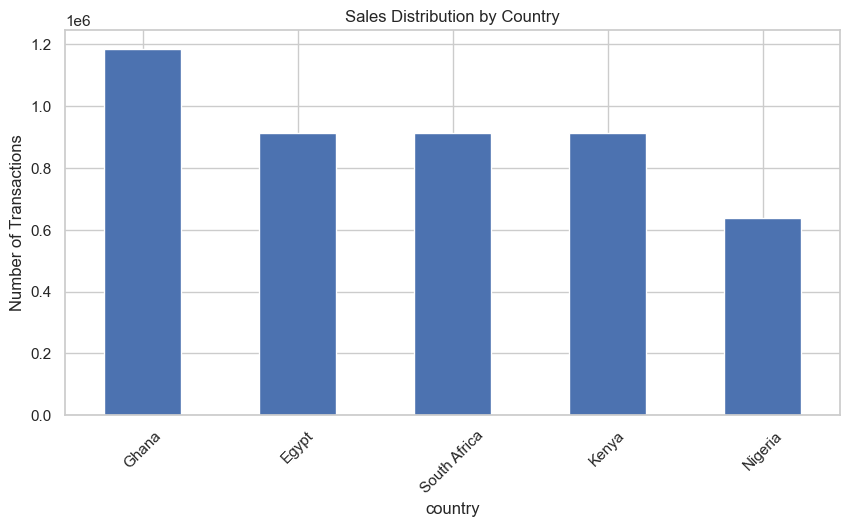

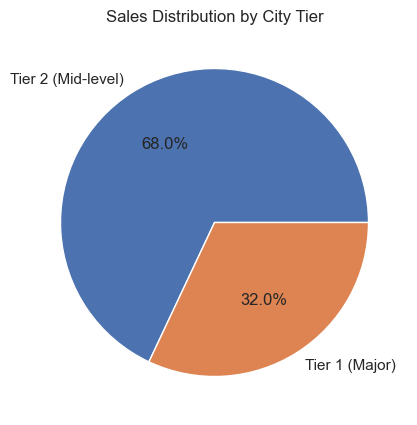

In [9]:
# 5. Categorical Variable Analysis
# Country distribution
plt.figure(figsize=(10, 5))
df['country'].value_counts().plot(kind='bar')
plt.title('Sales Distribution by Country')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.show()

# City tier distribution
plt.figure(figsize=(8, 5))
df['city_tier'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales Distribution by City Tier')
plt.show()


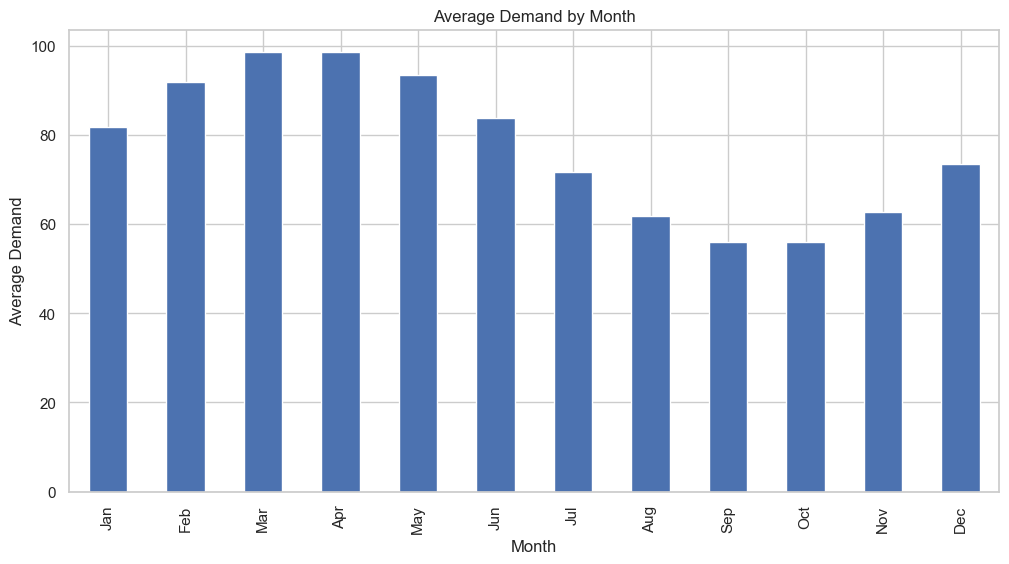

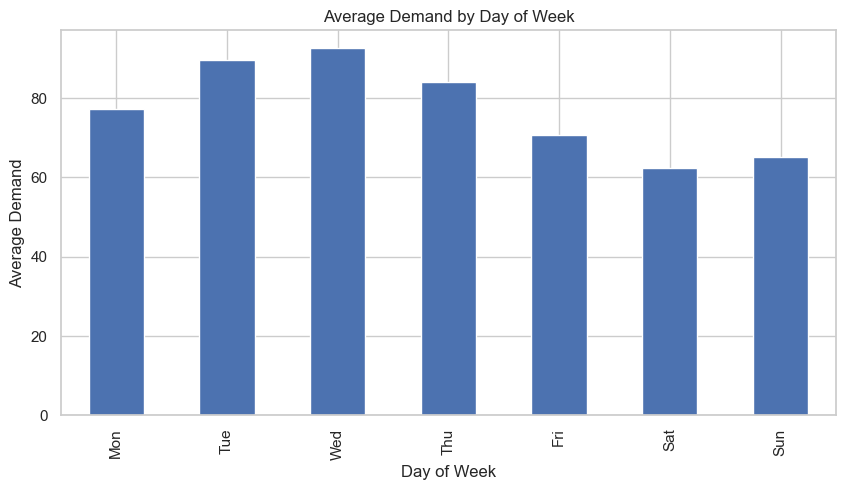

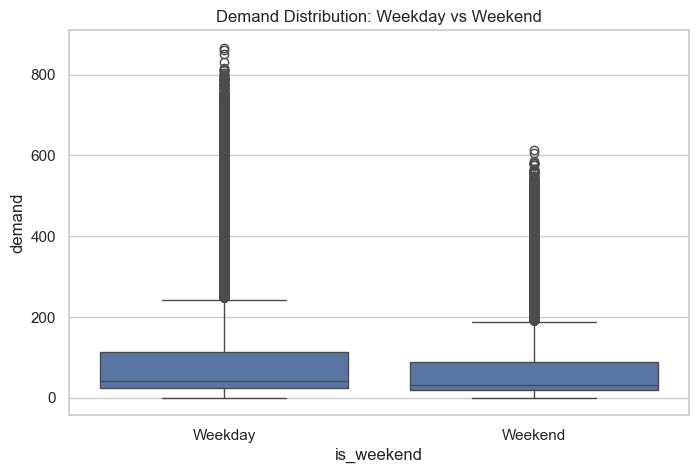

In [10]:
# 6. Time-Based Analysis
# Demand by month
plt.figure(figsize=(12, 6))
monthly_demand = df.groupby('month')['demand'].mean()
monthly_demand.plot(kind='bar')
plt.title('Average Demand by Month')
plt.xlabel('Month')
plt.ylabel('Average Demand')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

# Demand by day of week
plt.figure(figsize=(10, 5))
weekday_demand = df.groupby('day_of_week')['demand'].mean()
weekday_demand.plot(kind='bar')
plt.title('Average Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Demand')
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.show()

# Weekend vs Weekday comparison
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_weekend', y='demand')
plt.title('Demand Distribution: Weekday vs Weekend')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.show()


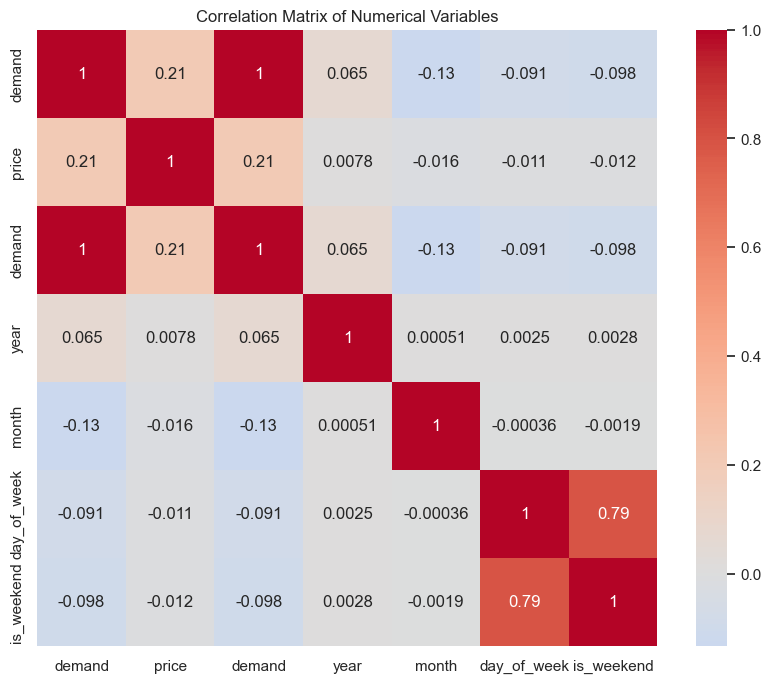

In [11]:
# 7. Correlation Analysis
# Select numerical columns for correlation
numerical_cols = ['demand', 'price', 'demand', 'year', 'month', 'day_of_week', 'is_weekend']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Variables')
plt.show()


Number of demand outliers: 390276
Percentage of outliers: 8.55%


C:\Users\ginik\miniconda3\envs\portfolio-1-start\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


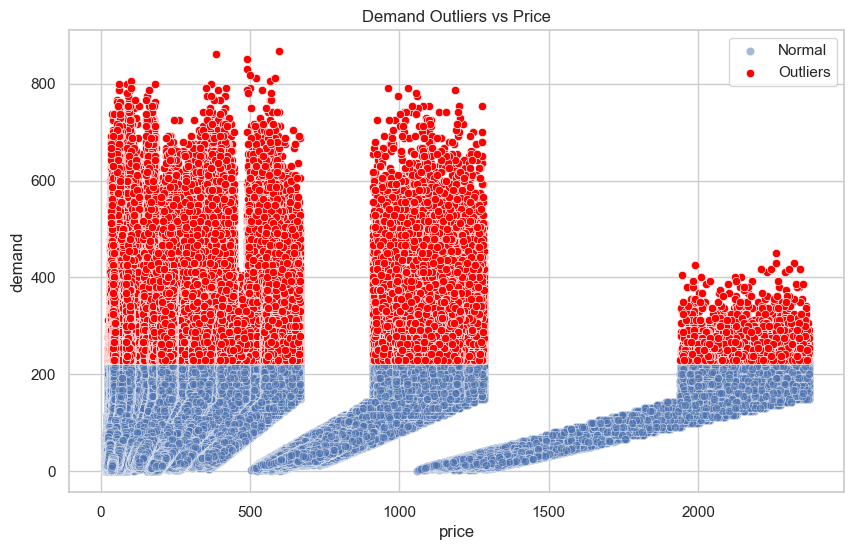

In [12]:
# 8. Outlier Detection
# Using IQR method for demand
Q1 = df['demand'].quantile(0.25)
Q3 = df['demand'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['demand'] < lower_bound) | (df['demand'] > upper_bound)]
print(f"Number of demand outliers: {len(outliers)}")
print(f"Percentage of outliers: {len(outliers)/len(df)*100:.2f}%")

# Visualize outliers
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='price', y='demand', alpha=0.5, label='Normal')
sns.scatterplot(data=outliers, x='price', y='demand', color='red', label='Outliers')
plt.title('Demand Outliers vs Price')
plt.legend()
plt.show()


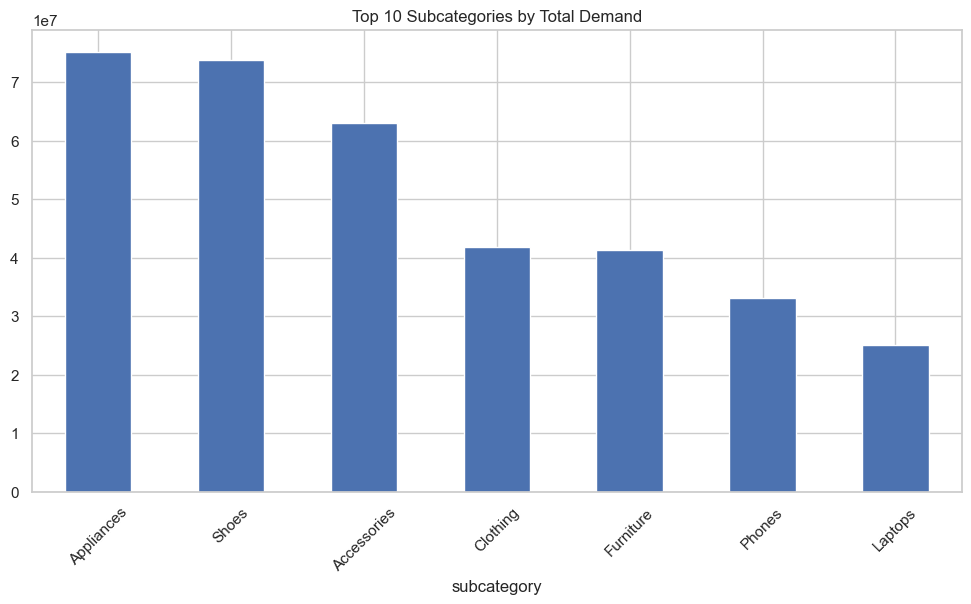

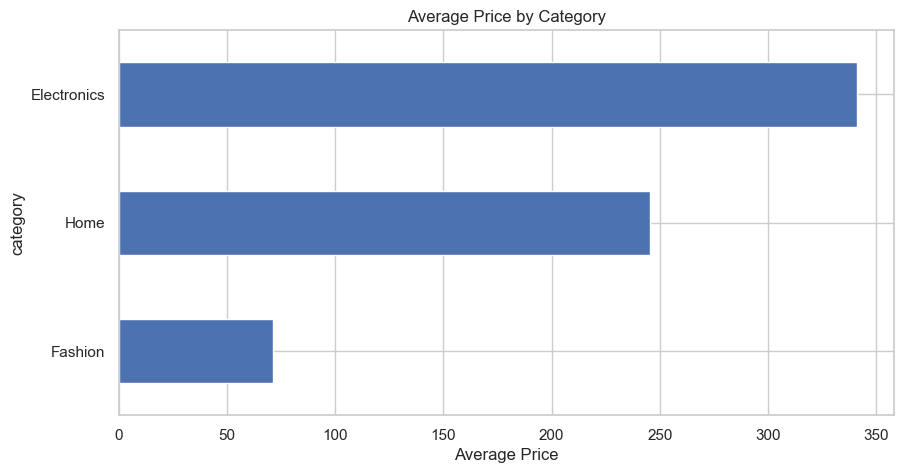

In [13]:
# 9. Category and Subcategory Analysis
# Top subcategories by demand
plt.figure(figsize=(12, 6))
top_subcats = df.groupby('subcategory')['demand'].sum().sort_values(ascending=False).head(10)
top_subcats.plot(kind='bar')
plt.title('Top 10 Subcategories by Total Demand')
plt.xticks(rotation=45)
plt.show()

# Average price by category
plt.figure(figsize=(10, 5))
avg_price_by_cat = df.groupby('category')['price'].mean().sort_values()
avg_price_by_cat.plot(kind='barh')
plt.title('Average Price by Category')
plt.xlabel('Average Price')
plt.show()


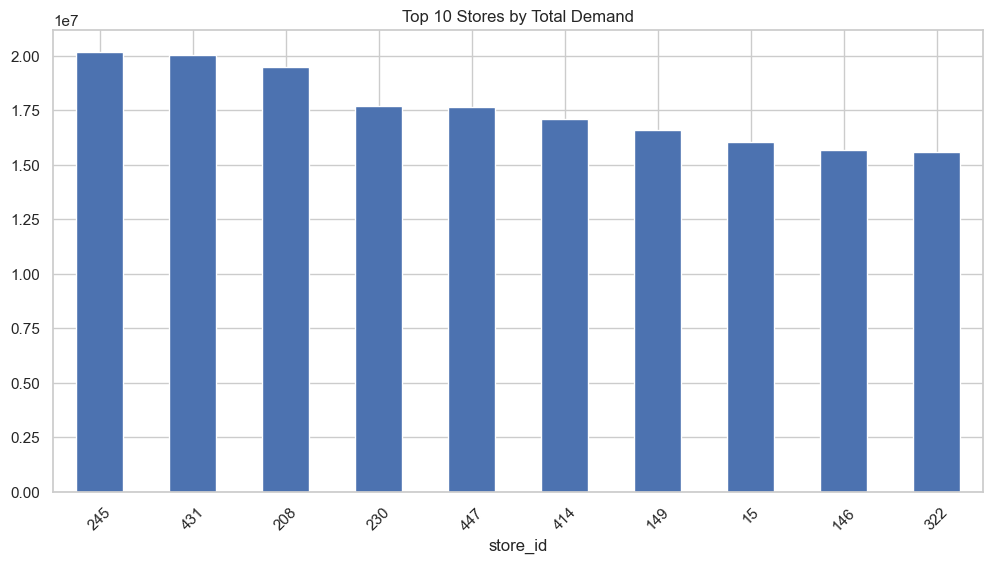

<Figure size 1200x600 with 0 Axes>

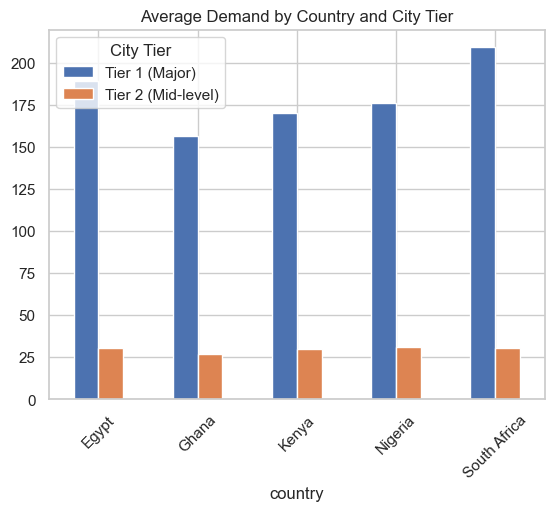

In [14]:
# 10. Store-Level Analysis
# Top performing stores
plt.figure(figsize=(12, 6))
top_stores = df.groupby('store_id')['demand'].sum().sort_values(ascending=False).head(10)
top_stores.plot(kind='bar')
plt.title('Top 10 Stores by Total Demand')
plt.xticks(rotation=45)
plt.show()

# Demand by country and city tier
plt.figure(figsize=(12, 6))
country_tier_demand = df.groupby(['country', 'city_tier'])['demand'].mean().unstack()
country_tier_demand.plot(kind='bar')
plt.title('Average Demand by Country and City Tier')
plt.xticks(rotation=45)
plt.legend(title='City Tier')
plt.show()


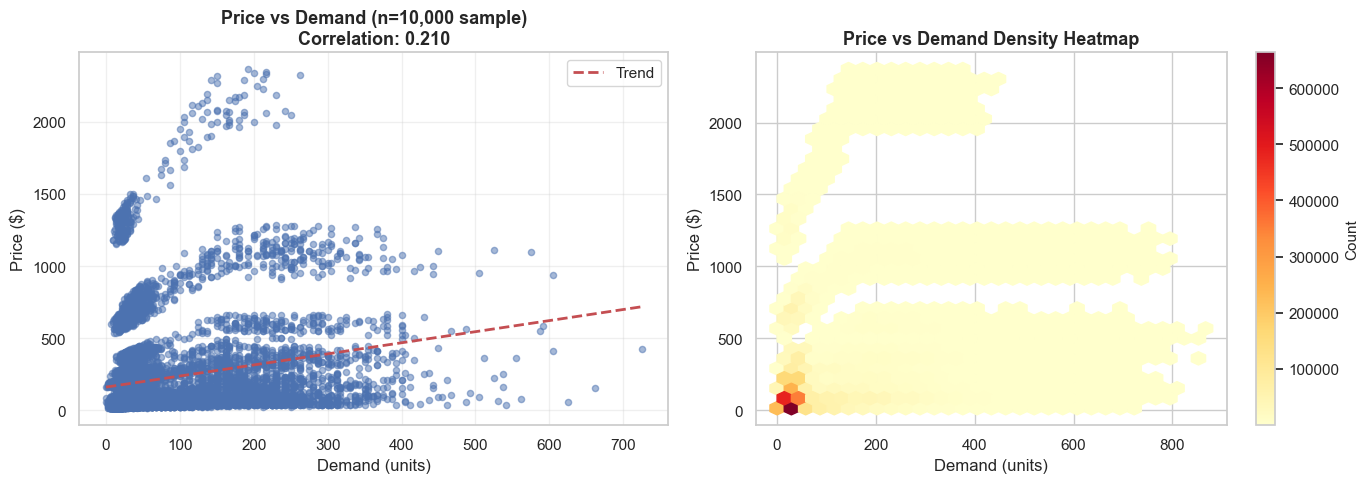

✅ Price-Demand Correlation: 0.2103
   Interpretation: Weak positive correlation
   As demand increases, price tends to increase (but with noise/variation)


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ==========================================
# Price vs Demand Correlation Analysis
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot: Price vs Demand (sample for clarity)
sample_df = df.sample(n=min(10000, len(df)), random_state=42)
axes[0].scatter(sample_df['demand'], sample_df['price'], alpha=0.5, s=20)
axes[0].set_xlabel('Demand (units)', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].set_title(f'Price vs Demand (n={len(sample_df):,} sample)\nCorrelation: {df["price"].corr(df["demand"]):.3f}', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(sample_df['demand'], sample_df['price'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(sample_df['demand']), p(sorted(sample_df['demand'])), "r--", linewidth=2, label='Trend')
axes[0].legend()

# 2. Hexbin plot: Density visualization
hb = axes[1].hexbin(df['demand'], df['price'], gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_xlabel('Demand (units)', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].set_title('Price vs Demand Density Heatmap', fontsize=13, fontweight='bold')
cbar = plt.colorbar(hb, ax=axes[1])
cbar.set_label('Count', fontsize=11)

plt.tight_layout()
plt.savefig('../output_price_demand_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Price-Demand Correlation: {df['price'].corr(df['demand']):.4f}")
print(f"   Interpretation: Weak positive correlation")
print(f"   As demand increases, price tends to increase (but with noise/variation)")

In [15]:
# Key Insights Summary
print("EDA Insights:")
print("1. Total dataset contains", len(df), "transactions across", df['store_id'].nunique(), "stores and", df['item_id'].nunique(), "items.")
print("2. Demand shows", "positive" if df['demand'].skew() > 0 else "negative", "skewness with mean =", df['demand'].mean().round(2))
print("3. Highest demand category:", df.groupby('category')['demand'].sum().idxmax())
print("4. Price and demand correlation:", correlation_matrix.loc['price', 'demand'].round(3))
print("5. Weekend demand is", "higher" if df[df['is_weekend']==1]['demand'].mean() > df[df['is_weekend']==0]['demand'].mean() else "lower", "than weekday demand.")
print("6. Outlier percentage in demand:", f"{len(outliers)/len(df)*100:.2f}%")

# Save key statistics for modeling
eda_stats = {
    'total_transactions': len(df),
    'unique_stores': df['store_id'].nunique(),
    'unique_items': df['item_id'].nunique(),
    'date_range': f"{df['date'].min()} to {df['date'].max()}",
    'demand_mean': df['demand'].mean(),
    'demand_std': df['demand'].std(),
    'price_mean': df['price'].mean(),
    'outlier_percentage': len(outliers)/len(df)*100
}

import json
with open('../data/eda_stats.json', 'w') as f:
    json.dump(eda_stats, f, indent=4, default=str)

print("\nEDA statistics saved to '../data/eda_stats.json'")


EDA Insights:
1. Total dataset contains 4565000 transactions across 48 stores and 50 items.
2. Demand shows positive skewness with mean = 77.41
3. Highest demand category: Electronics
4. Price and demand correlation: demand    0.21
demand    0.21
Name: price, dtype: float64
5. Weekend demand is lower than weekday demand.
6. Outlier percentage in demand: 8.55%

EDA statistics saved to '../data/eda_stats.json'
